In [80]:
import os
import re
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [ ]:
# load in fmri data
brain_data_base_path = "/home/zachkaras/fmri/fmri_model_data"
code_brain_data_path = f"{brain_data_base_path}/clean"
prose_brain_data_path = f"{brain_data_base_path}/clean_prose"

# load in atlases
# mask file
maskfile = "../pipeline/atlases/MNI152_T1_2mm_brain_mask.nii"
mask_nii = nib.load(maskfile)
mask = mask_nii.get_fdata()

# getting indexes of brain in MNI file
brain_idx = np.argwhere(mask)

# mni brain file
mni_brain_file = "../pipeline/atlases/MNI152_T1_2mm_brain.nii.gz"
mni_brain_nii = nib.load(mni_brain_file)
mni_brain = mni_brain_nii.get_fdata()

# Schaefer atlas
atlas_file = "../pipeline/atlases/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz"
atlas_nii = nib.load(atlas_file)
atlas = atlas_nii.get_fdata()
 

In [107]:


code_brain_data = os.listdir(code_brain_data_path)
for b in code_brain_data:
    brain_path = f"{code_brain_data_path}/{b}"
    data_nii = nib.load(brain_path)
    data = data_nii.get_fdata()
    break

# load in atlases


# isolate voxel values associated with specific ROIs


# find ROIs of interest



In [82]:
code_brain_data

['108.nii.gz',
 '109.nii.gz',
 '129.nii.gz',
 '144.nii.gz',
 '204.nii.gz',
 '150.nii.gz',
 '151.nii.gz',
 '133.nii.gz',
 '119.nii.gz',
 '118.nii.gz',
 '121.nii.gz',
 '203.nii.gz',
 '117.nii.gz',
 '138.nii.gz',
 '122.nii.gz',
 '112.nii.gz',
 '105.nii.gz',
 '111.nii.gz',
 '101.nii.gz',
 '141.nii.gz',
 '102.nii.gz',
 '201.nii.gz',
 '125.nii.gz',
 '134.nii.gz',
 '142.nii.gz']

In [19]:
# plot for voxel values

In [20]:
# load in embeddings
embedding_basepath = "/home/zachkaras/fmri/fmri_model_data/model_embeddings"
code_basepath = f"{embedding_basepath}/code"
prose_basepath = f"{embedding_basepath}/prose"

code_embedding_models = os.listdir(code_basepath)
code_embedding_models = [f for f in code_embedding_models if not re.search('csv', f)]

prose_embedding_models = os.listdir(prose_basepath)
prose_embedding_models = [f for f in prose_embedding_models if not re.search('csv', f)]



In [78]:
# plot for embeddings
for model in code_embedding_models:
    print(model)
    embedding_path = f"{code_basepath}/{model}"
    embeddings = os.listdir(embedding_path)
    
    for e in embeddings:
        matrix = torch.load(f"{embedding_path}/{e}")
        break
    break

matrix = torch.load(f"{embedding_path}/question_0.pt")
matrix2 = torch.load(f"{code_basepath}/deepseek_2b/question_0.pt")
matrix3 = torch.load(f"{code_basepath}/deepseek_2b/question_2.pt")

starcoder2_7b


In [63]:
matrix2

tensor([[-0.3379, -0.3857,  1.6865,  ...,  1.7920,  1.6729, -1.7041],
        [-0.2986, -0.2627,  1.0605,  ...,  0.5762,  2.1484,  0.1613],
        [-1.1162, -0.5698,  2.1738,  ...,  0.2422,  2.0059, -0.8281],
        ...,
        [ 0.9365, -4.0039,  0.8945,  ...,  0.8257,  2.1348, -0.6973],
        [ 0.3020, -0.8003,  1.4570,  ...,  1.0430,  2.1309,  0.4519],
        [-1.6406, -1.0879, -0.1133,  ...,  0.9346,  2.5293,  0.2742]],
       dtype=torch.float16)

In [64]:
print(torch.max(matrix), torch.min(matrix))
mat_min = torch.min(matrix)
mat_max = torch.max(matrix)

tensor(79.1250, dtype=torch.float16) tensor(-46.7500, dtype=torch.float16)


In [ ]:
# normalize matrix
# norm_matrix = (matrix - mat_min) / (mat_max - mat_min)

In [ ]:
# norm_matrix

tensor([[0.3948, 0.3960, 0.4236,  ..., 0.4072, 0.4207, 0.3909],
        [0.4045, 0.4182, 0.4248,  ..., 0.4143, 0.4180, 0.4160],
        [0.4089, 0.4084, 0.4231,  ..., 0.4062, 0.4248, 0.4304],
        ...,
        [0.3882, 0.4075, 0.4133,  ..., 0.4260, 0.4111, 0.4226],
        [0.4038, 0.4163, 0.4390,  ..., 0.4124, 0.3911, 0.4109],
        [0.4102, 0.4004, 0.4172,  ..., 0.4058, 0.4165, 0.4048]],
       dtype=torch.float16)

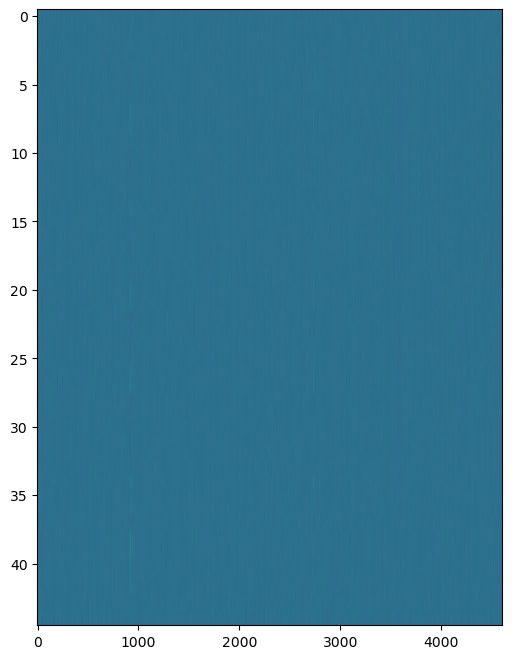

In [69]:
plt.figure(figsize=(6,8))
plt.imshow(matrix, cmap='viridis', aspect='auto')
plt.show()

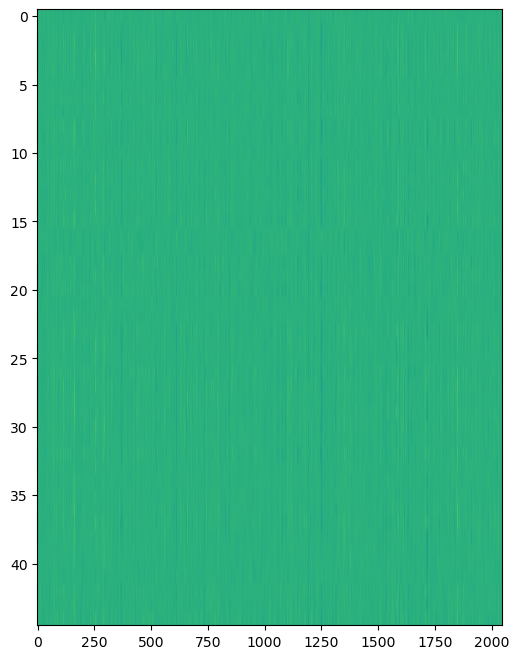

In [76]:
plt.figure(figsize=(6,8))
plt.imshow(matrix2, cmap='viridis', aspect='auto')
plt.show()

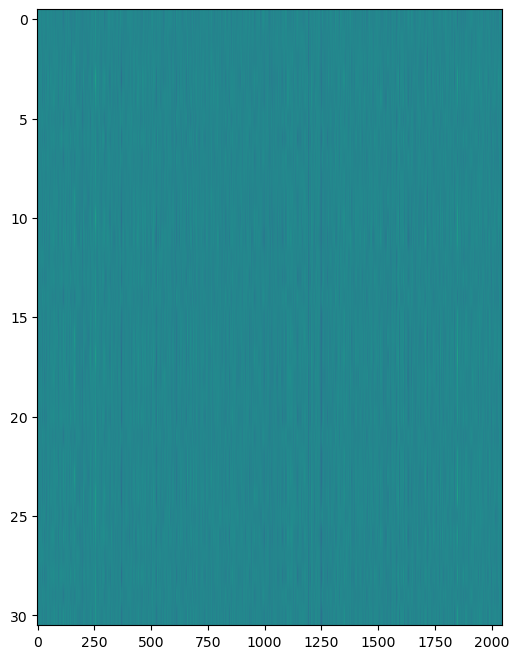

In [79]:
plt.figure(figsize=(6,8))
plt.imshow(matrix3, cmap='viridis', aspect='auto')
plt.show()